一、导入相关库

In [1]:
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd
import polars as pl
import alphalens as al
import matplotlib.pyplot as plt
from datetime import datetime

# 配置文件
try:
    import config_local as config
except ImportError:
    import config

# 导入数据接口sdk
import zenidatasdk as zd
client = zd.Client(
    base_url = config.ZENI_URL,
    username = config.ZENI_USERNAME,
    password = config.ZENI_PASSWORD,
)

# 忽视警告信息
warnings.filterwarnings(action = 'ignore')

二、获取数据

In [2]:
# 历史回测区间
init_date = '2026-03-01'
start_date = '2026-03-01'
end_date = str(datetime.today().date())
index_symbol = rf"000300.XSHG"

In [3]:
# 获取指数成分股数据据
index_weights_df = client.get_index_constituents_df(
    index_symbol = index_symbol,
    start_date = start_date,
    end_date = end_date
)
index_weights_df = index_weights_df.rename(columns = {"date": "datetime"})
symbols = index_weights_df["symbol"].unique().tolist()
index_weights_df

,datetime,index_symbol,update_date,symbol,weight,display_name
0,2026-03-02,000300.XSHG,2026-02-27,000001.XSHE,0.411,平安银行
1,2026-03-02,000300.XSHG,2026-02-27,000002.XSHE,0.128,万科A
2,2026-03-02,000300.XSHG,2026-02-27,000063.XSHE,0.484,中兴通讯
3,2026-03-02,000300.XSHG,2026-02-27,000100.XSHE,0.402,TCL科技
4,2026-03-02,000300.XSHG,2026-02-27,000157.XSHE,0.193,中联重科
...,...,...,...,...,...,...
10195,2026-04-17,000300.XSHG,2026-03-31,688303.XSHG,0.056,大全能源
10196,2026-04-17,000300.XSHG,2026-03-31,688396.XSHG,0.097,华润微
10197,2026-04-17,000300.XSHG,2026-03-31,688472.XSHG,0.078,阿特斯
10198,2026-04-17,000300.XSHG,2026-03-31,688506.XSHG,0.094,百利天恒


In [11]:
# 获取分钟bar数据
bars_1m_df = client.get_kline_df(
    symbol = symbols,
    start_date = init_date,
    end_date = end_date,
    frequency = "1m",
    adjust_type = "post",
    market = "cn_stock",
)
bars_1m_df

,open,high,low,close,volume,symbol,amount,datetime
0,1588.01,1589.47,1582.15,1582.15,27270.37,000001.XSHE,43236885.00,2026-03-02 09:31:00
1,1582.15,1585.08,1582.15,1585.08,5543.17,000001.XSHE,8777475.00,2026-03-02 09:32:00
2,1583.62,1585.08,1583.62,1583.62,7794.46,000001.XSHE,12346595.00,2026-03-02 09:33:00
3,1582.15,1583.62,1582.15,1583.62,3022.68,000001.XSHE,4785243.00,2026-03-02 09:34:00
4,1583.62,1583.62,1582.15,1583.62,3843.94,000001.XSHE,6083712.00,2026-03-02 09:35:00
...,...,...,...,...,...,...,...,...
2303995,103.87,103.92,103.86,103.91,431906.00,688981.XSHG,44871368.89,2026-04-15 14:56:00
2303996,103.90,103.99,103.90,103.99,249807.00,688981.XSHG,25966768.80,2026-04-15 14:57:00
2303997,103.99,103.99,103.99,103.99,9277.00,688981.XSHG,964697.80,2026-04-15 14:58:00
2303998,103.99,103.99,103.99,103.99,0.00,688981.XSHG,0.00,2026-04-15 14:59:00


In [ ]:
tmp_Dataset_path = rf"C:\Users\zy\Desktop\tmp_Dataset"
bars_1m_df_path = os.path.join(tmp_Dataset_path, rf"bars_1m_df.csv")

if "bars_1m_df" in locals() and not os.path.exists(bars_1m_df_path):
    bars_1m_df.to_csv(bars_1m_df_path, index = False)
else:
    bars_1m_df = pd.read_csv(bars_1m_df_path)

In [ ]:
# # 获取日频估值数据
# fundamental_1d_df = client.get_valuation_df(
#     symbols = symbols,
#     start_date = start_date,
#     end_date = end_date,
#     fields = "datetime,symbol,market_cap,circulating_market_cap,turnover_ratio,pe_ratio,pb_ratio,dividend_ratio"
# )
# fundamental_1d_df
#
#
# # 构建市值数据
# # market_cap、circulating_market_cap
# mkt_cap_name = "market_cap"
# market_cap_df = fundamental_1d_df.set_index(["datetime", "symbol"])[[mkt_cap_name]]
#
# # 负数和无穷值 & 对数处理
# market_cap_df[mkt_cap_name] = np.where((market_cap_df[mkt_cap_name] <= 0) | (~np.isfinite(market_cap_df[mkt_cap_name])), 0, market_cap_df[mkt_cap_name])
# market_cap_df[f"{mkt_cap_name}_log"] = np.log1p(market_cap_df[mkt_cap_name])
# market_cap = market_cap_df[f"{mkt_cap_name}_log"]
# market_cap

In [6]:
# 获取行业数据
industry_constituents_df = client.get_industry_constituents_composite_df(
    symbols = symbols,
    category = "sw_l1",
    start_date = start_date,
    end_date = end_date
)

# 构建双重索引的行业数据
industries = industry_constituents_df.set_index(["datetime", "symbol"])["industry_name"]
industries

datetime    symbol     
2016-01-04  000034.XSHE    农林牧渔I
            000048.XSHE    农林牧渔I
            000592.XSHE    农林牧渔I
            000639.XSHE    农林牧渔I
            000713.XSHE    农林牧渔I
                           ...  
2026-04-15  600315.XSHG    美容护理I
            603193.XSHG    美容护理I
            603605.XSHG    美容护理I
            603983.XSHG    美容护理I
            605009.XSHG    美容护理I
Name: industry_name, Length: 5750861, dtype: object

三、构建价格数据

In [7]:
# 多资产价格数据(开盘价买入)
prices_df = bars_1d_df[bars_1d_df["datetime"] >= start_date]
prices = prices_df.pivot_table(index = "datetime", columns = "symbol", values = "open")
prices

symbol,000005.XSHE,000006.XSHE,000008.XSHE,000010.XSHE,000011.XSHE,000012.XSHE,000014.XSHE,000016.XSHE,000018.XSHE,000019.XSHE,...,688733.XSHG,688739.XSHG,688766.XSHG,688776.XSHG,688778.XSHG,688779.XSHG,688788.XSHG,688789.XSHG,688798.XSHG,688800.XSHG
datetime,,,,,,,,,,,,,,,,,,,,,
2016-01-04,102.23,476.84,313.85,135.06,50.80,273.77,206.45,154.58,91.44,54.61,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-05,83.42,401.53,255.99,113.92,43.35,233.13,172.57,128.18,76.73,46.36,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-06,91.19,418.59,290.33,114.19,43.87,241.38,174.38,133.77,82.80,46.26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-07,92.42,421.50,284.79,116.45,43.70,241.18,172.75,133.77,82.45,46.81,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-08,88.02,396.12,271.58,109.93,41.08,228.18,163.99,125.50,78.54,42.54,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-08,NaN,437.90,74.73,50.11,38.38,162.56,151.87,77.94,NaN,49.98,...,27.34,27.78,982.80,114.55,125.33,10.89,117.80,157.56,93.62,156.79
2026-04-09,NaN,443.07,75.54,51.05,39.21,162.56,152.78,78.67,NaN,51.27,...,27.89,27.97,970.42,119.12,129.75,11.03,121.15,158.67,95.81,162.98
2026-04-10,NaN,441.00,74.46,49.72,38.93,162.56,153.01,77.45,NaN,51.46,...,27.79,27.56,1032.15,117.78,127.12,11.01,127.03,154.60,95.99,164.34


四、构建因子变量

In [8]:
def f_abnretavg_000(bars: pd.DataFrame, f_name = 'f_0001', min_periods: int = 5) -> pd.DataFrame:
    """
    factor_intro: 平均异常日收益率因子
    category: abnretavg
    category_intro: 注意力类因子
    subcategory: None
    subcategory_intro: 异常收益率
    min_periods: 5
    source: None
    author: 魏丰协

    Parameters
    ----------
    bars: pd.DataFrame
        日频, bars
        ['datetime', 'symbol', 'open', 'high', 'low', 'close', 'volume']
    f_name: str
        因子名称
    min_periods: int
        计算窗口期，默认为20（1个月交易日）

    Returns
    -------
    pd.DataFrame
        因子值，包含列：['datetime', 'symbol', 'factor_name', 'factor_value']
    """

    rolling_window_len = 60

    bars['return'] = bars.groupby('symbol')['close'].transform(
        lambda close: (close - close.shift(1)) / close.shift(1)
    )
    bars['avg_return'] = bars.groupby('datetime')['return'].transform('mean')
    bars['abnormal_return'] = (bars['return'] - bars['avg_return']) ** 2
    bars['abnretavg'] = bars.groupby('symbol')['abnormal_return'].transform(
        lambda x: x.rolling(window = rolling_window_len, min_periods = min_periods).mean()
    )


    abnretavg_long = bars.reset_index()
    abnretavg_long = abnretavg_long.rename(columns = {'abnretavg': 'factor_value'})
    abnretavg_long = abnretavg_long[['datetime', 'symbol', 'factor_value']].copy()
    abnretavg_long['factor_name'] = f_name
    abnretavg_long = abnretavg_long[['datetime', 'symbol', 'factor_name', 'factor_value']].copy()

    return abnretavg_long

In [9]:
# 计算因子数据
factors_df = f_abnretavg_000(
    bars = bars_1d_df,
    f_name = 'abnretavg',
    min_periods = 5,
) # 因子函数 func()
# 因子值 shift 1 转换成实际使用时间(T+1)
factors_df["factor_value"] = factors_df.groupby('symbol')['factor_value'].transform(lambda x: x.shift(1))
factors_df

,datetime,symbol,factor_name,factor_value
0,2015-01-05,000005.XSHE,abnretavg,NaN
1,2015-01-05,000006.XSHE,abnretavg,NaN
2,2015-01-05,000008.XSHE,abnretavg,NaN
3,2015-01-05,000010.XSHE,abnretavg,NaN
4,2015-01-05,000011.XSHE,abnretavg,NaN
...,...,...,...,...
6096147,2026-04-14,688779.XSHG,abnretavg,0.000833
6096148,2026-04-14,688788.XSHG,abnretavg,0.000852
6096149,2026-04-14,688789.XSHG,abnretavg,0.000561
6096150,2026-04-14,688798.XSHG,abnretavg,0.000376


In [10]:
# 与指数的交易日历、历史成分股数据对齐
factors_df = pd.merge(index_weights_df[["datetime", "symbol"]], factors_df, how = "left", on = ["datetime", "symbol"])
# 转换成[datetime, symbol]双重索引的factor_table
factors = factors_df.pivot_table(index = ["datetime", "symbol"], columns = "factor_name", values = "factor_value")
factors

factor_name             abnretavg
datetime   symbol                
2016-01-04 000008.XSHE   0.001483
           000010.XSHE   0.001004
           000011.XSHE   0.000956
           000014.XSHE   0.001359
           000016.XSHE   0.000969
...                           ...
2026-04-14 688776.XSHG   0.001356
           688779.XSHG   0.000833
           688789.XSHG   0.000561
           688798.XSHG   0.000376
           688800.XSHG   0.001490

[2494976 rows x 1 columns]

In [11]:
factors.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 2494976 entries, (Timestamp('2016-01-04 00:00:00'), '000008.XSHE') to (Timestamp('2026-04-14 00:00:00'), '688800.XSHG')
Data columns (total 1 columns):
 #   Column     Dtype  
---  ------     -----  
 0   abnretavg  float64
dtypes: float64(1)
memory usage: 28.6+ MB


五、合并因子与目标变量

In [12]:
# 调用alphalens进行数据清洗
factor_data = al.utils.get_clean_factor_and_forward_returns(
    factor=factors,
    prices=prices,
    periods=(1, 5, 20),
    bins=None,
    quantiles=7,
    groupby=None,
    groupby_labels=None,
    binning_by_group=False,
    filter_zscore=20,
    max_loss=0.25,
    zero_aware=False,
    cumulative_returns=True
)
factor_data

Dropped 0.8% entries from factor data: 0.8% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 25.0%, not exceeded: OK!


1D        5D       20D    factor  \
date       asset                                                 
2016-01-04 000008.XSHE -0.184356 -0.159089 -0.294631  0.001483   
           000010.XSHE -0.156523 -0.232267 -0.184066  0.001004   
           000011.XSHE -0.146654 -0.229134 -0.326969  0.000956   
           000014.XSHE -0.164108 -0.229741 -0.260402  0.001359   
           000016.XSHE -0.170785 -0.224350 -0.400893  0.000969   
...                          ...       ...       ...       ...   
2026-03-16 688776.XSHG -0.083979 -0.226926 -0.262006  0.001516   
           688779.XSHG  0.012386 -0.099917 -0.066061  0.000856   
           688789.XSHG -0.008778 -0.063387 -0.094256  0.000363   
           688798.XSHG  0.014198 -0.053934 -0.059554  0.000382   
           688800.XSHG  0.104382  0.014032  0.071024  0.001489   

                        factor_quantile  
date       asset                         
2016-01-04 000008.XSHE                7  
           000010.XSHE                5  
           000011.XSHE                5  
           000014.XSHE                6  
           000016.XSHE                5  
...                                 ...  
2026-03-16 688776.XSHG                7  
           688779.XSHG                5  
           688789.XSHG                3  
           688798.XSHG                3  
           688800.XSHG                7  

[2474976 rows x 5 columns]

六、alphalens因子测试

Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,0.000022,0.000491,0.000137,0.000060,354531,14.324624
2,0.000090,0.000642,0.000238,0.000086,353366,14.277553
3,0.000138,0.000784,0.000337,0.000114,353890,14.298725
4,0.000187,0.000946,0.000452,0.000147,351474,14.201107
5,0.000250,0.001231,0.000597,0.000188,353912,14.299613
6,0.000341,0.001818,0.000821,0.000256,353878,14.298240
7,0.000479,0.009284,0.001478,0.000684,353925,14.300139


Returns Analysis


,1D,5D,20D
Ann. alpha,-0.081,-0.075,-0.063
beta,1.091,1.080,1.087
Mean Period Wise Return Top Quantile (bps),-5.572,-4.756,-3.128
Mean Period Wise Return Bottom Quantile (bps),6.476,6.072,4.992
Mean Period Wise Spread (bps),-12.048,-11.718,-9.094


<Figure size 640x480 with 0 Axes>

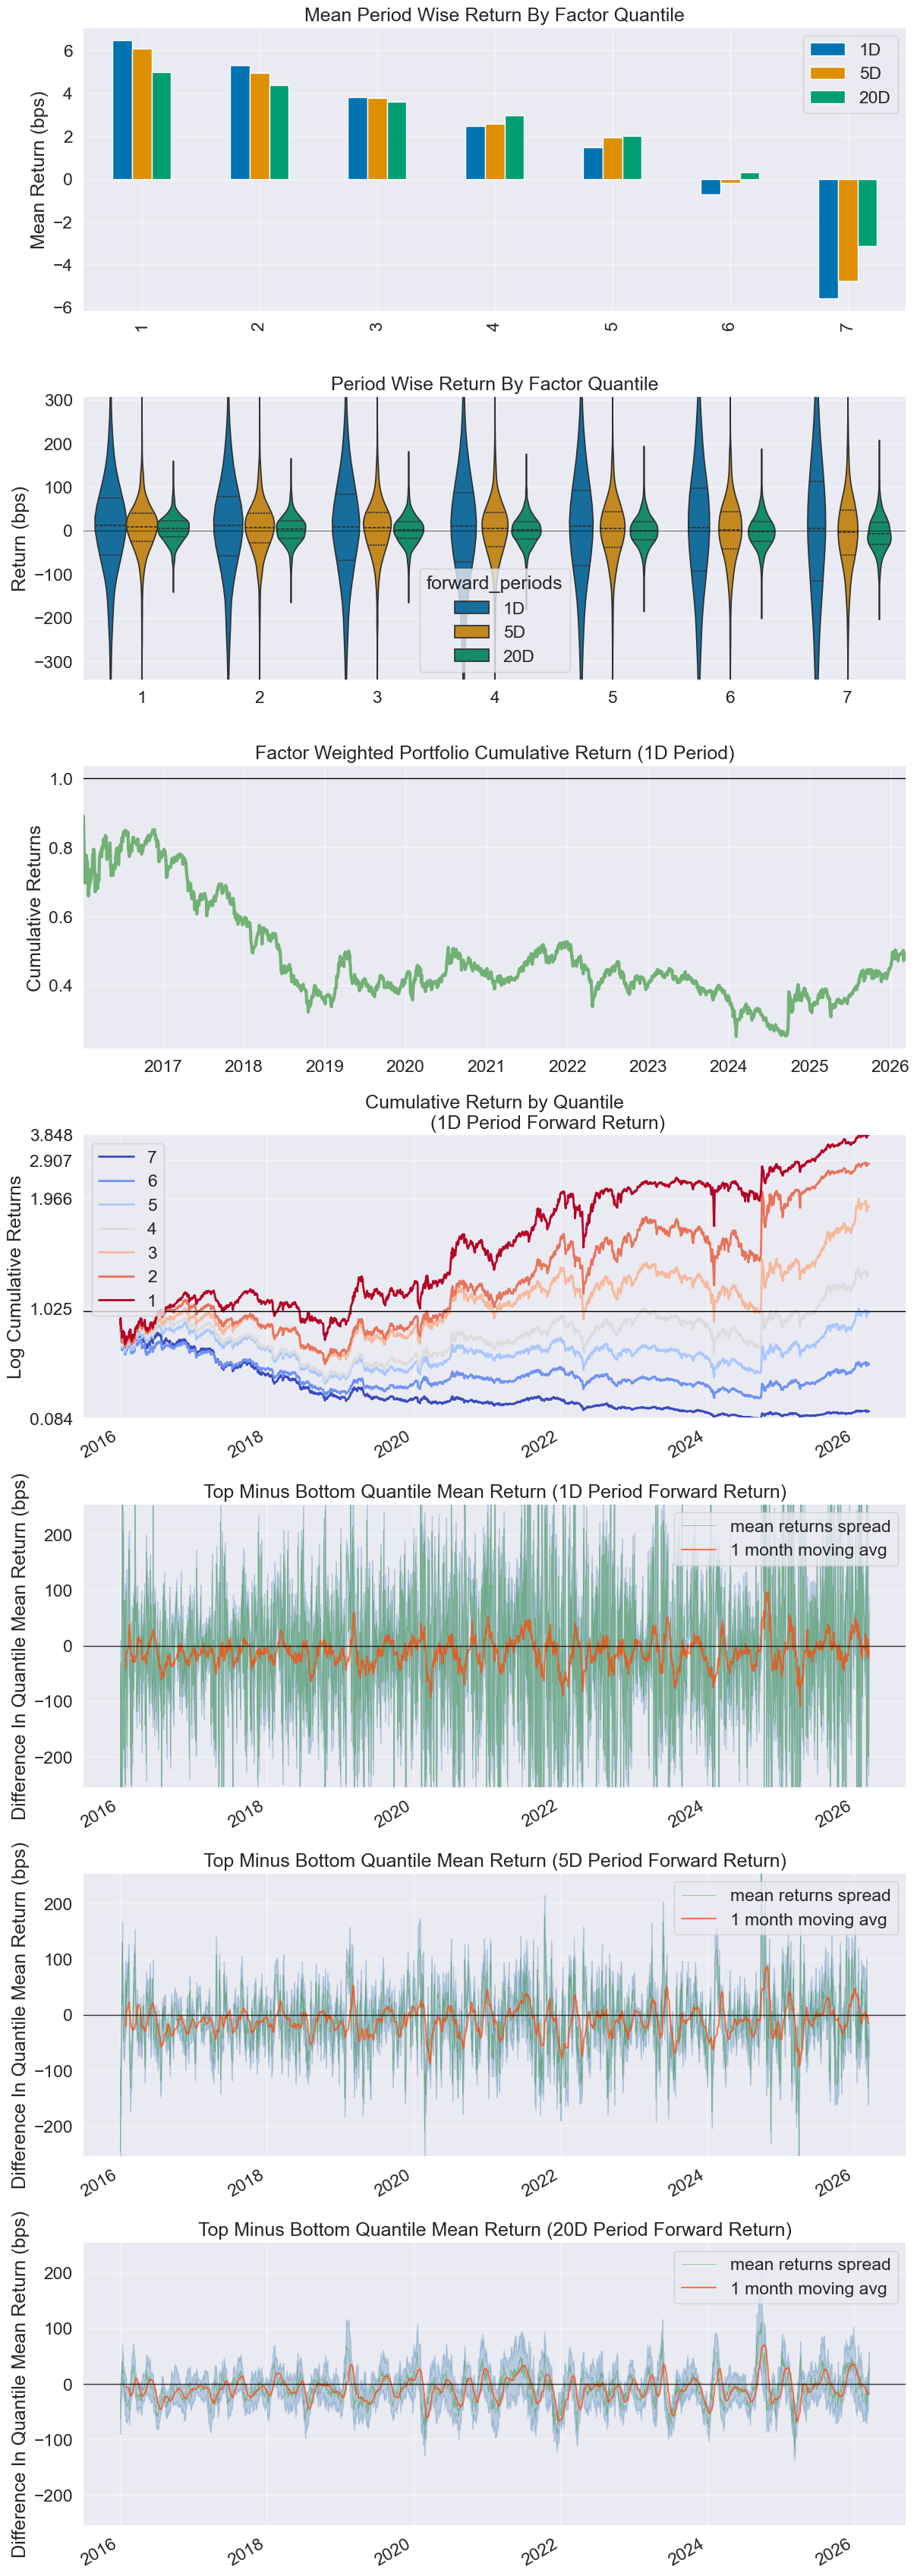

Information Analysis


,1D,5D,20D
IC Mean,-0.043,-0.073,-0.106
IC Std.,0.158,0.154,0.157
Risk-Adjusted IC,-0.272,-0.477,-0.670
t-stat(IC),-13.527,-23.727,-33.338
p-value(IC),0.000,0.000,0.000
IC Skew,0.015,0.116,0.131
IC Kurtosis,0.085,-0.123,-0.065


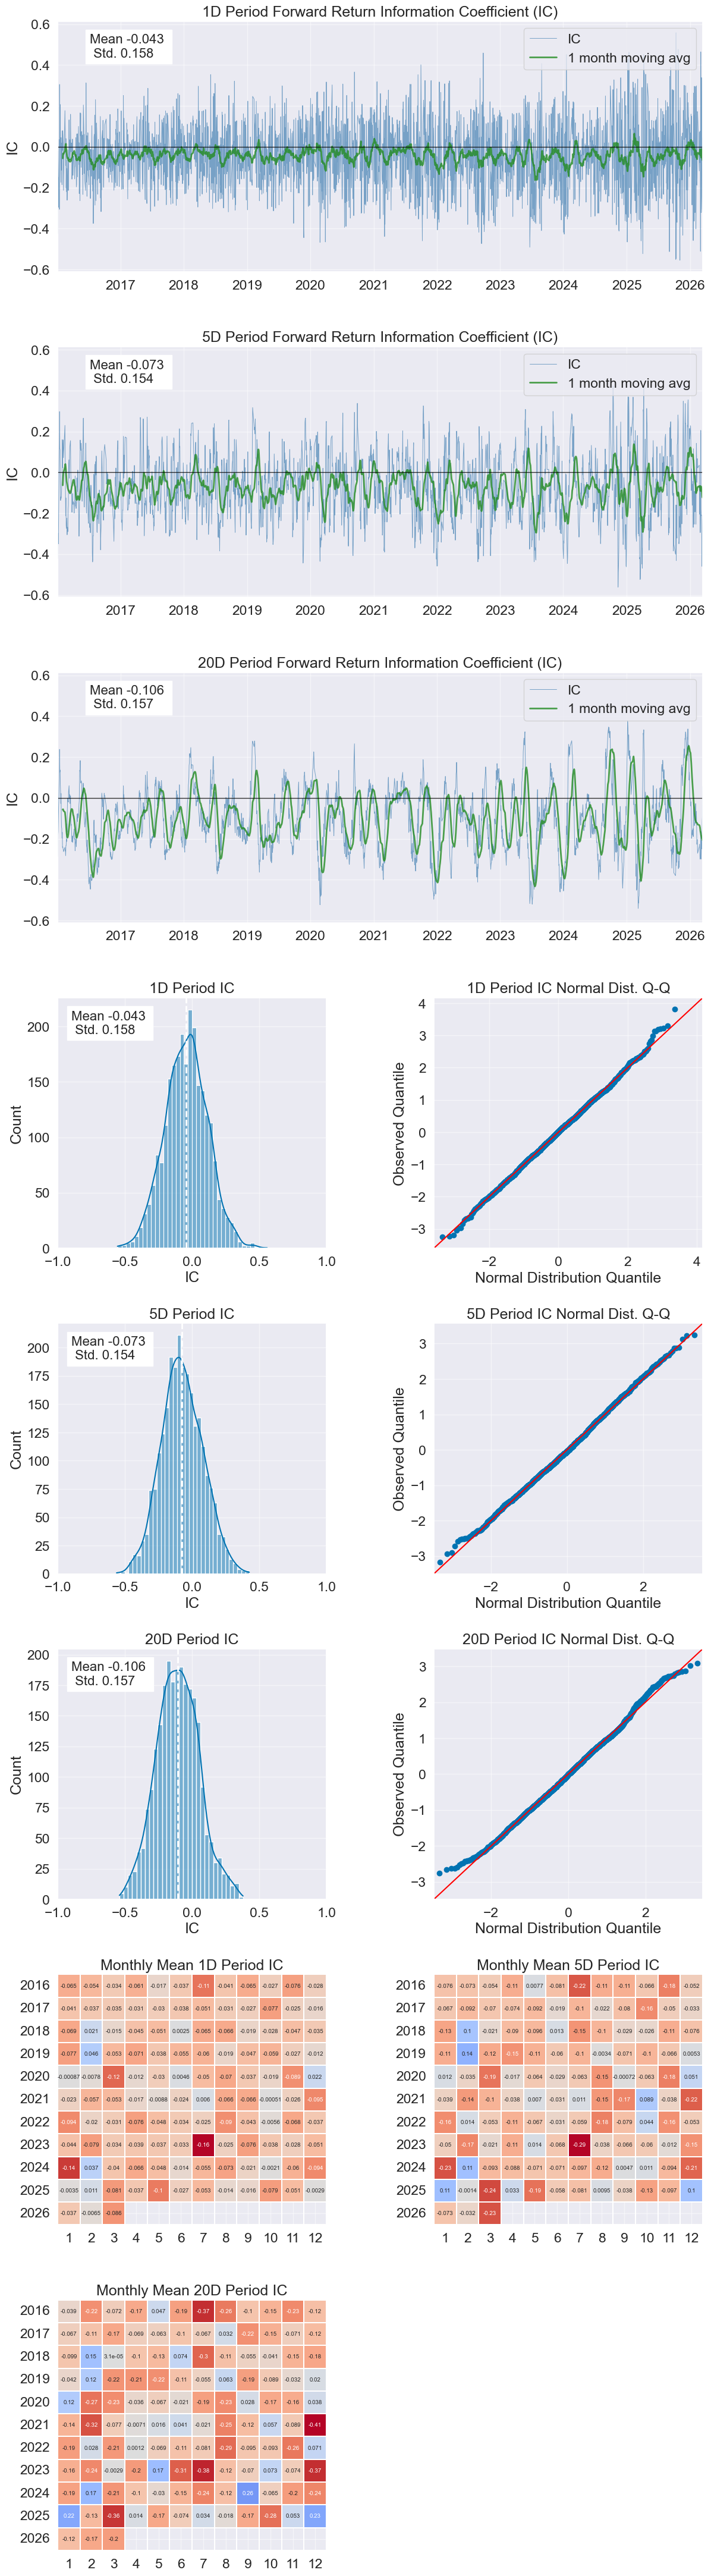

Turnover Analysis


,1D,5D,20D
Quantile 1 Mean Turnover,0.037,0.124,0.335
Quantile 2 Mean Turnover,0.083,0.256,0.573
Quantile 3 Mean Turnover,0.099,0.302,0.634
Quantile 4 Mean Turnover,0.106,0.320,0.653
Quantile 5 Mean Turnover,0.099,0.304,0.641
Quantile 6 Mean Turnover,0.078,0.249,0.571
Quantile 7 Mean Turnover,0.032,0.110,0.319


,1D,5D,20D
Mean Factor Rank Autocorrelation,0.995,0.968,0.831


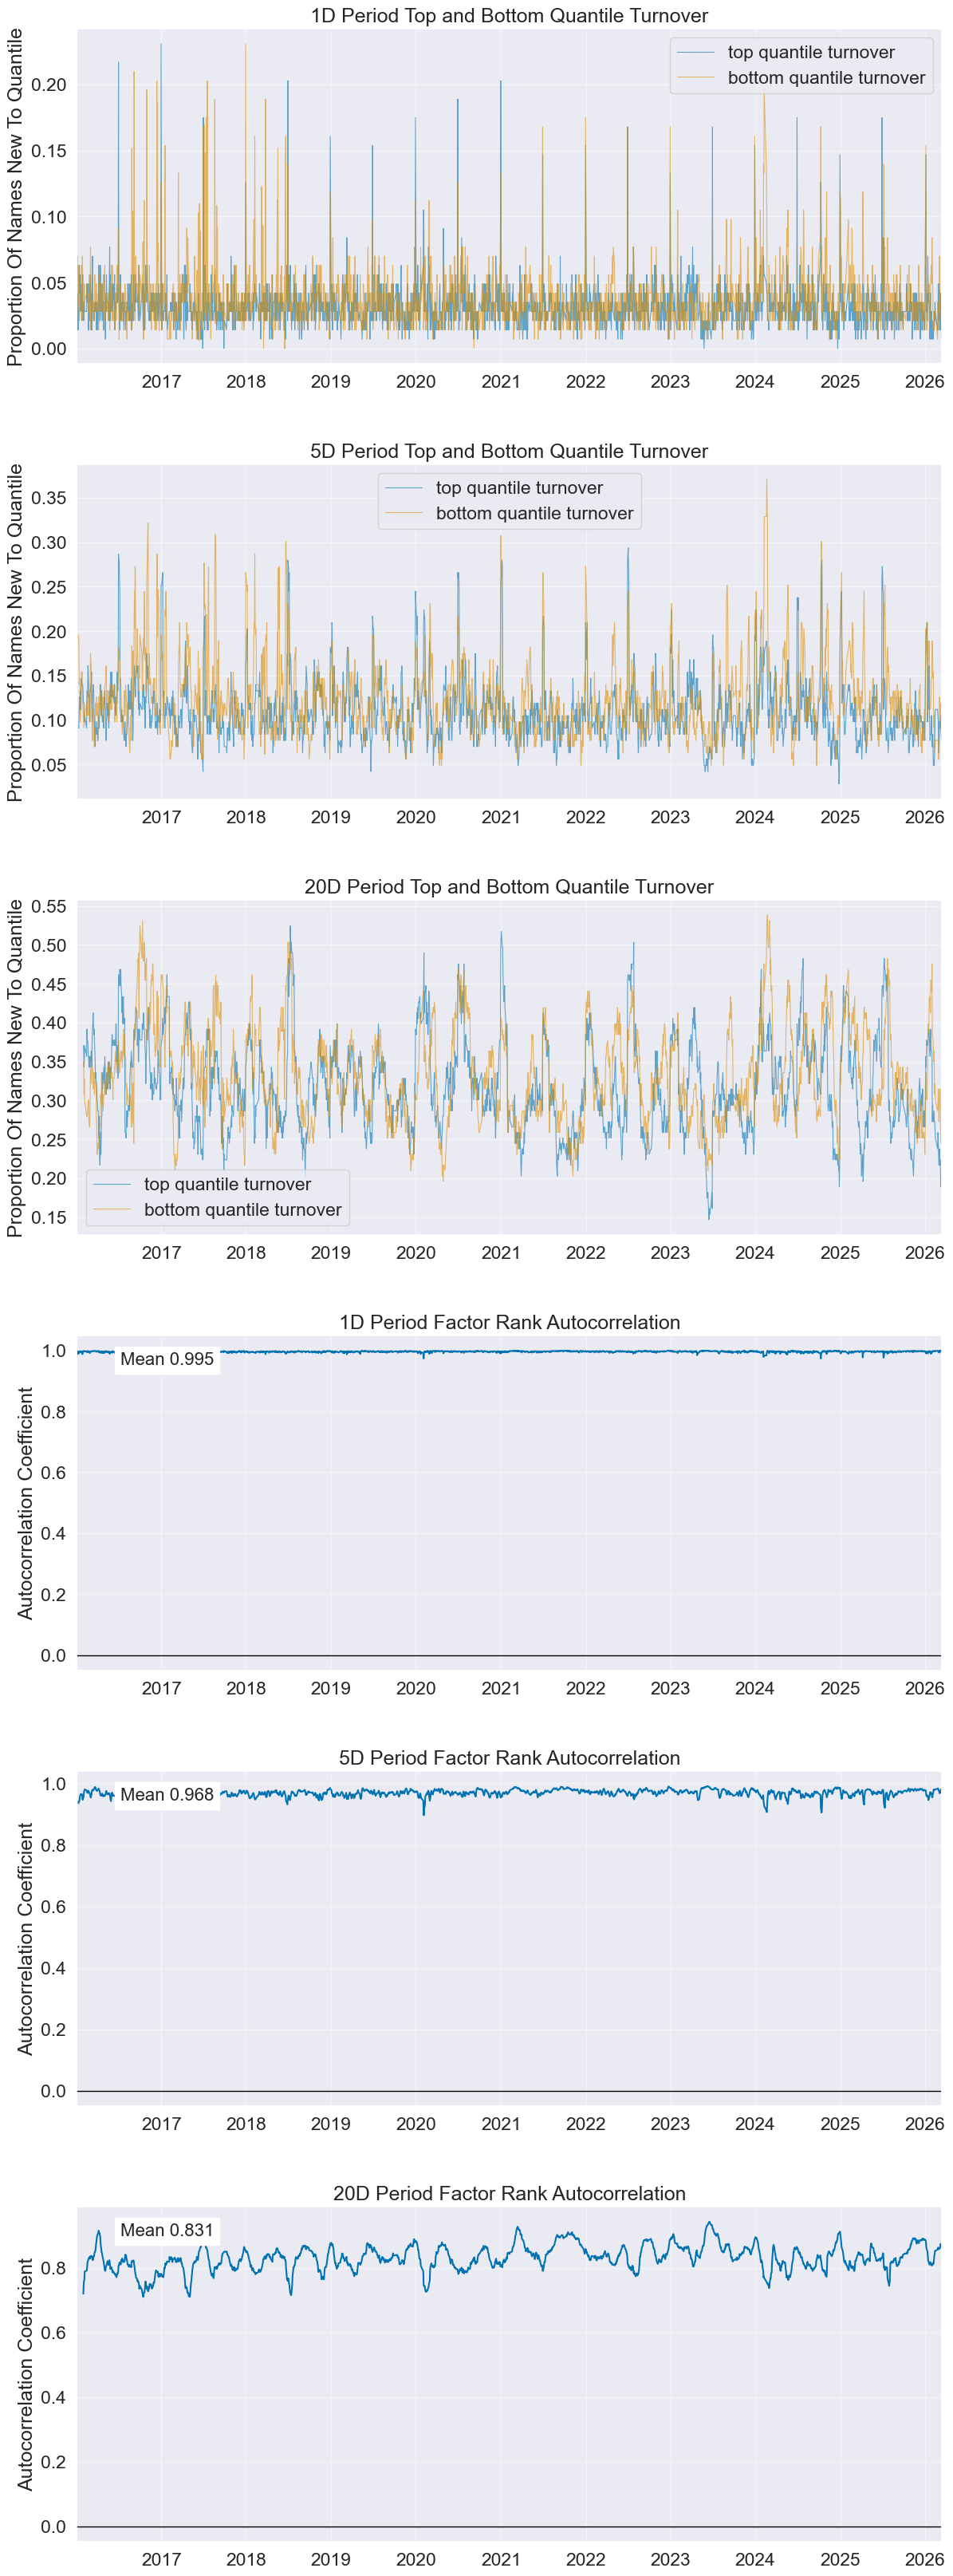

In [13]:
# 调用alphalens进行因子评估
al.tears.create_full_tear_sheet(
    factor_data=factor_data,
    long_short=False,
    group_neutral=False,
    by_group=False
)